In [18]:
import warnings
import logging
from pathlib import Path


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    BLR,
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    NormalLikelihood,
    make_prior,
    plot_centiles,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)


In [19]:
#Load metadata
metadata_path = Path("/home/traaffneu/bersal/digitalrodent/data/MetaData/Awake.tsv")
meta_df = pd.read_csv(metadata_path, sep="\t")  

print(meta_df.columns.tolist())
display(meta_df.head())

sex_df = meta_df[["Participant_Id", "Sex"]].drop_duplicates()
assert sex_df["Participant_Id"].is_unique, "some animal has conflicting sex values"

print(sex_df["Sex"].value_counts(dropna=False))

#Load DR components
# Comma-separated despite the .tsv name, with spaces before the commas
dr_path = Path("/home/traaffneu/bersal/digitalrodent/results/dual_regression/Awake.csv")
dr_df = pd.read_csv(dr_path, sep=r"\s*,\s*", engine="python")

comp_cols = [c for c in dr_df.columns if c.startswith("comp")]
dr_df[comp_cols] = dr_df[comp_cols].apply(pd.to_numeric)

# sub-0100100 -> 100100, to match the metadata
dr_df["Participant_Id"] = dr_df["subject"].str.extract(r"sub-(\d+)")[0].astype(int)

print(len(dr_df), "scans,", dr_df["Participant_Id"].nunique(), "animals")
display(dr_df.head())

['Scan_id', 'Participant_Id', 'Session', 'Dataset_name', 'Sex', 'Age(week)', 'Rodent.strain', 'MRI', 'Coil', 'fMRI.sequence', 'MRI T.R.', 'MRI T.E.', 'Anesthesia', 'Anesthesia amount', 'Ventilation', 'head-plate', 'Habituation', 'FD average', 'FD maximum', 'tSNR', 'comp1', 'comp2', 'comp3', 'comp4', 'comp5', 'comp6', 'comp7', 'comp8', 'comp9', 'comp10', 'comp11', 'comp12', 'comp13', 'comp14', 'comp15', 'comp16', 'comp17', 'comp18']


,Scan_id,Participant_Id,Session,Dataset_name,Sex,Age(week),Rodent.strain,MRI,Coil,fMRI.sequence,...,comp9,comp10,comp11,comp12,comp13,comp14,comp15,comp16,comp17,comp18
0,NaN,100100,1,Awake,M,7-9,C57BL/6,9.4,y,GE-EPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,100101,1,Awake,M,7-9,C57BL/6,9.4,y,GE-EPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,100102,1,Awake,M,7-9,C57BL/6,9.4,y,GE-EPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,100103,1,Awake,M,7-9,C57BL/6,9.4,y,GE-EPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,100200,1,Awake,M,16-20,C57BL/6,7.0,n,GE-EPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Sex
M      110
F       88
NaN     10
Name: count, dtype: int64
1552 scans, 193 animals


,subject,comp1,comp2,comp3,comp4,comp5,comp6,comp7,comp8,comp9,comp10,comp11,comp12,comp13,comp14,comp15,comp16,comp17,comp18,Participant_Id
0,sub-0100100_ses-1_run-1_task-rest_bold_cleaned,0.080495,0.098474,0.114468,0.075640,0.062307,0.054010,0.046308,0.074807,0.073279,0.038724,0.076055,0.073271,0.047264,0.041018,0.061271,0.074997,0.044077,0.048933,100100
1,sub-0100101_ses-1_run-1_task-rest_bold_cleaned,0.124921,0.118759,0.141769,0.089887,0.063125,0.070274,0.058579,0.059824,0.097931,0.056971,0.118733,0.076449,0.050775,0.040541,0.054388,0.071685,0.076146,0.054609,100101
2,sub-0100102_ses-1_run-1_task-rest_bold_cleaned,0.078614,0.109265,0.121399,0.081270,0.069492,0.070683,0.059093,0.067771,0.103806,0.069914,0.105347,0.111538,0.055667,0.040283,0.082954,0.085356,0.067969,0.049316,100102
3,sub-0100103_ses-1_run-1_task-rest_bold_cleaned,0.085199,0.162053,0.140070,0.079652,0.093249,0.069337,0.062055,0.054130,0.107579,0.052930,0.090121,0.062174,0.049908,0.040879,0.046181,0.073097,0.047932,0.061054,100103
4,sub-0100200_ses-1_run-1_task-rest_bold_cleaned,0.444197,0.218354,0.361291,0.189678,0.159223,0.156644,0.221429,0.361740,0.252028,0.113044,0.307416,0.366787,0.165517,0.115571,0.187124,0.186063,0.187952,0.196527,100200


In [20]:
#merge and checks
df = dr_df.merge(sex_df, on="Participant_Id", how="left")
df["sex_encoded"] = df["Sex"].map({"M": 0, "F": 1}).astype("float64")

print(df["Sex"].value_counts(dropna=False))
print(len(df), "scans,", df["Participant_Id"].nunique(), "animals")

# Scans whose animal wasn't found in the metadata
unmatched = df[df["Sex"].isna()]["Participant_Id"].unique()
print("Unmatched animals:", unmatched)

Sex
M    860
F    692
Name: count, dtype: int64
1552 scans, 193 animals
Unmatched animals: []


count    193.000000
mean       8.041451
std        9.945599
min        1.000000
25%        1.000000
50%        3.000000
75%       16.000000
max       32.000000
dtype: float64


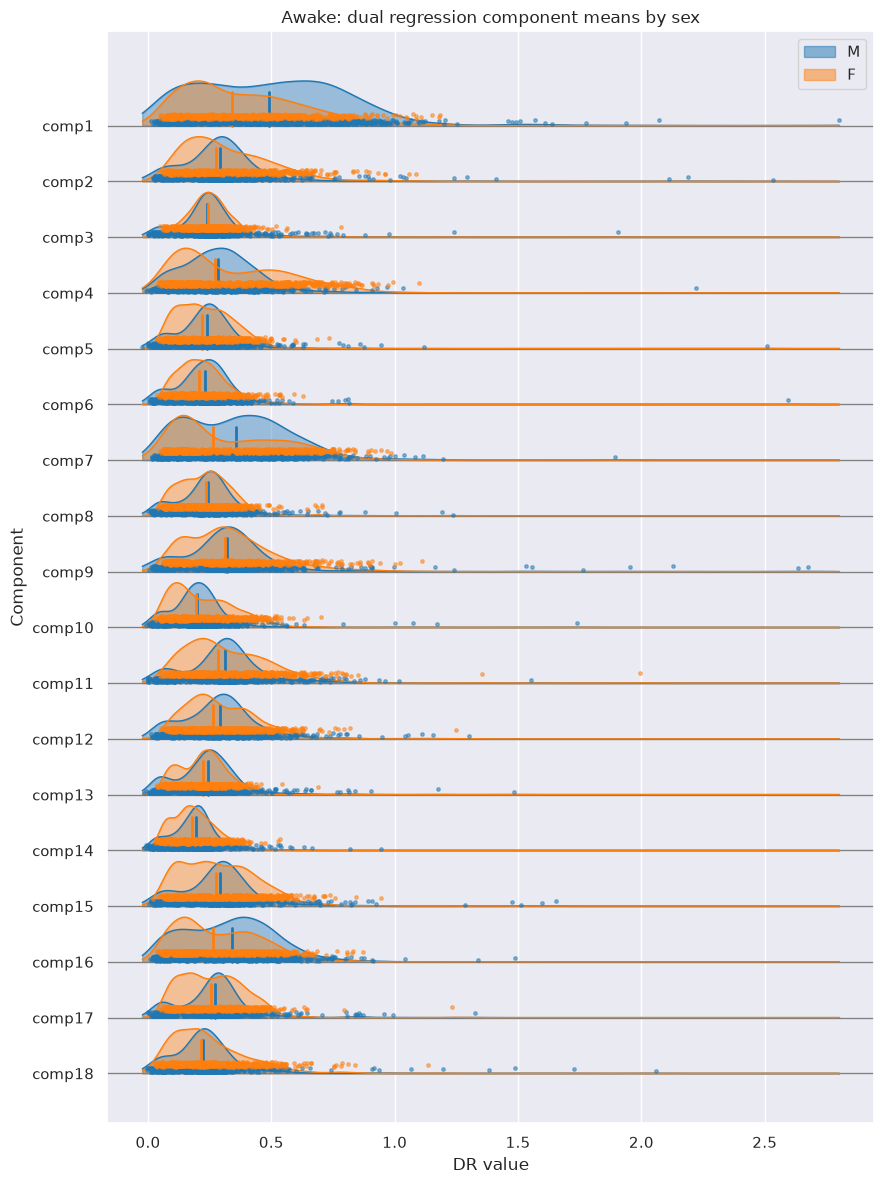

In [21]:
# Scans per animal
scans_per_animal = df.groupby("Participant_Id").size()
print(scans_per_animal.describe())

from scipy.stats import gaussian_kde

sex_colors = {"M": "tab:blue", "F": "tab:orange"}
fig, ax = plt.subplots(figsize=(9, 12))

x_min, x_max = df[comp_cols].min().min(), df[comp_cols].max().max()
x_grid = np.linspace(x_min, x_max, 500)
rng = np.random.default_rng(0)

for i, comp in enumerate(comp_cols[::-1]):  # comp1 at the top
    ax.axhline(i, color="grey", lw=1)

    for j, (sex, color) in enumerate(sex_colors.items()):
        values = df.loc[df["Sex"] == sex, comp].dropna().values
        kde = gaussian_kde(values)(x_grid)
        kde = kde / kde.max() * 0.8

        ax.fill_between(x_grid, i, i + kde, color=color, alpha=0.4)
        ax.plot(x_grid, i + kde, color=color, lw=1)

        # Points: M slightly lower, F slightly higher, so they don't overlap
        jitter = rng.uniform(0.02, 0.1, size=len(values)) + j * 0.1
        ax.scatter(values, i + jitter, s=6, color=color, alpha=0.5, zorder=3)

        # Median per sex
        med = np.median(values)
        ax.plot([med, med], [i, i + 0.6], color=color, lw=2)

ax.set_yticks(range(len(comp_cols)))
ax.set_yticklabels(comp_cols[::-1])
ax.set_xlabel("DR value")
ax.set_ylabel("Component")
ax.set_title("Awake: dual regression component means by sex")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.5) for c in sex_colors.values()],
          labels=list(sex_colors.keys()))
plt.tight_layout()
plt.show()

Train: 1270 scans, 155 mice
Test:  282 scans, 38 mice
Overlap: set()


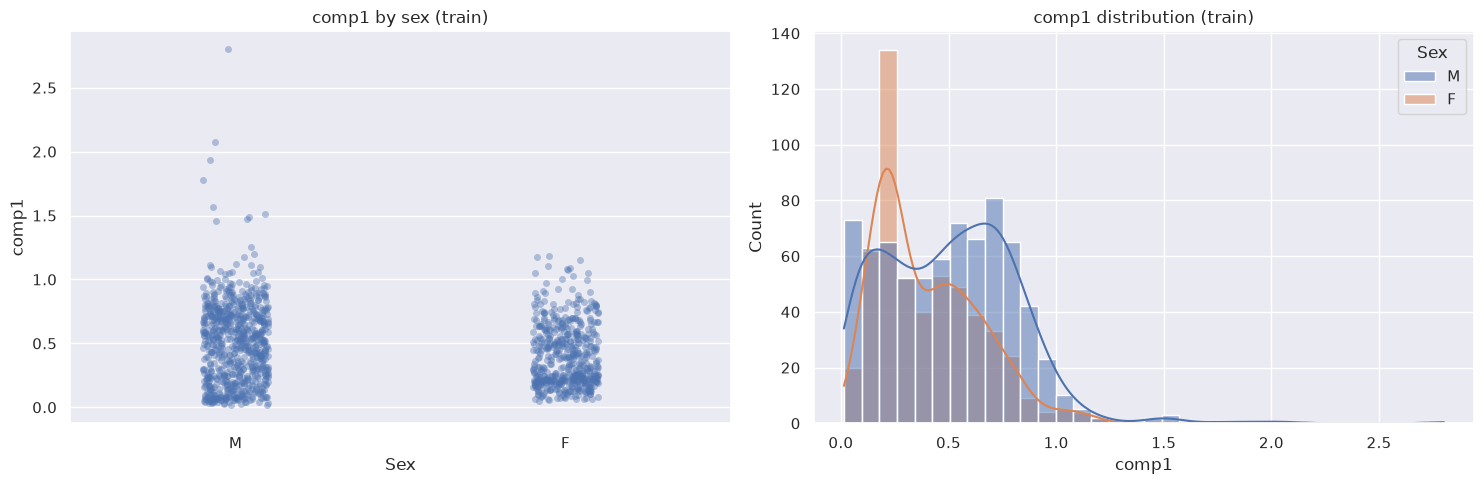

In [22]:
# split train/test by mouse, stratified by sex
rng = np.random.default_rng(42)  # fixed seed
test_frac = 0.2

# 1. One row per mouse
mice = df[["Participant_Id", "Sex"]].drop_duplicates()

# 2 + 3. Pick 20% of the mice within each sex
test_mice = []
for sex, group in mice.groupby("Sex"):
    ids = group["Participant_Id"].values
    n_test = int(round(test_frac * len(ids)))
    test_mice.extend(rng.choice(ids, size=n_test, replace=False))

# 4. True for rows belonging to a test mouse
is_test = df["Participant_Id"].isin(test_mice)

# 5. The two tables
train_df = df[~is_test].copy()
test_df = df[is_test].copy()

# 6. Checks
print("Train:", len(train_df), "scans,", train_df["Participant_Id"].nunique(), "mice")
print("Test: ", len(test_df), "scans,", test_df["Participant_Id"].nunique(), "mice")
print("Overlap:", set(train_df["Participant_Id"]) & set(test_df["Participant_Id"]))

# Define covariates, batch effects, and features to model
covariates = ["sex_encoded"]
batch_effects = []
feature_to_model = comp_cols  # all 18 components

train = NormData.from_dataframe(
    name="train",
    dataframe=train_df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=feature_to_model,
    remove_Nan=False,
)
test = NormData.from_dataframe(
    name="test",
    dataframe=test_df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=feature_to_model,
    remove_Nan=False,
)

# Visualize one component as a check
feature_to_plot = feature_to_model[0]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(data=train_df, x="Sex", y=feature_to_plot, alpha=0.4, ax=ax[0])
ax[0].set_title(f"{feature_to_plot} by sex (train)")

sns.histplot(data=train_df, x=feature_to_plot, hue="Sex", kde=True, ax=ax[1])
ax[1].set_title(f"{feature_to_plot} distribution (train)")

plt.tight_layout()
plt.show()

In [23]:
# Initialize and Fit Normative Model 
model = NormativeModel(
    BLR(heteroskedastic=True),
    inscaler="standardize",
    outscaler="standardize",
)

model.fit_predict(train, test)

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decoration

<xarray.NormData> Size: 452kB
Dimensions:            (observations: 282, response_vars: 18, covariates: 1,
                        batch_effect_dims: 1, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 2kB 0 1 2 3 4 ... 278 279 280 281
  * response_vars      (response_vars) <U6 432B 'comp1' 'comp2' ... 'comp18'
  * covariates         (covariates) <U11 44B 'sex_encoded'
  * batch_effect_dims  (batch_effect_dims) <U18 72B 'dummy_batch_effect'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) int64 2kB 0 1 2 3 4 ... 278 279 280 281
    Y                  (observations, response_vars) float64 41kB 0.4377 ... ...
    X                  (observations, covariates) float64 2kB 0.0 0.0 ... 1.0
    batch_effects      (observations, batch_effect_dims) <U32 36kB '0.0' ... ...
    Z                  (observations, response_vars) float64 41kB -0.2151 ......
    centiles           (centile, observations, response_vars) float64 203kB -...
    baseline_logp      (observations, response_vars) float64 41kB -0.7866 ......
    logp               (observations, response_vars) float64 41kB -1.023 ... ...
    Yhat               (observations, response_vars) float64 41kB 0.5056 ... ...
    statistics         (response_vars, statistic) float64 2kB 0.06554 ... 1.057
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           test
    unique_batch_effects:           {np.str_('dummy_batch_effect'): ['0.0']}
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('sex_encoded'): {'min': 0.0, 'ma...
    batch_effect_covariate_ranges:  {np.str_('dummy_batch_effect'): {'0.0': {...

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


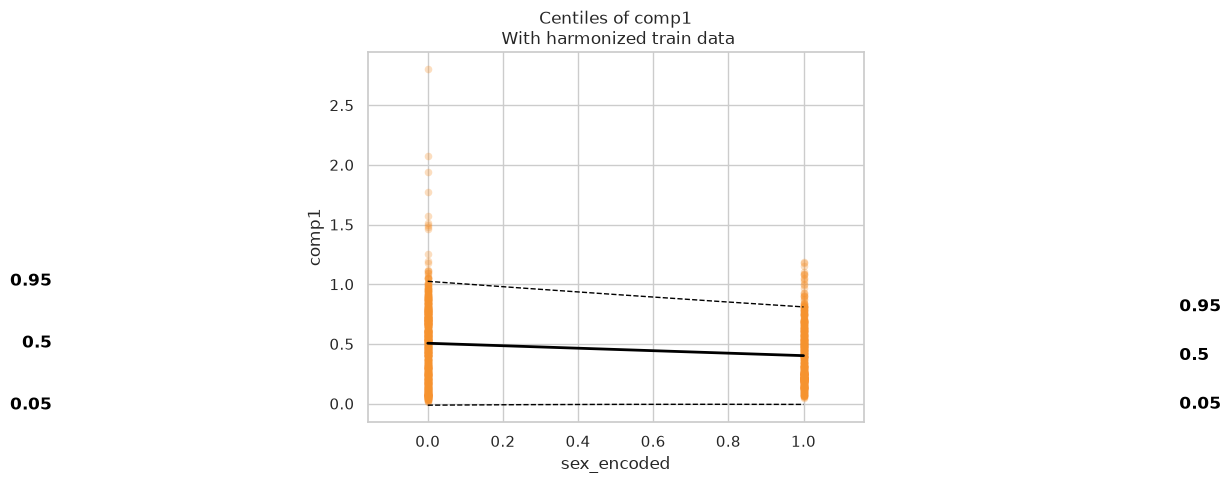

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


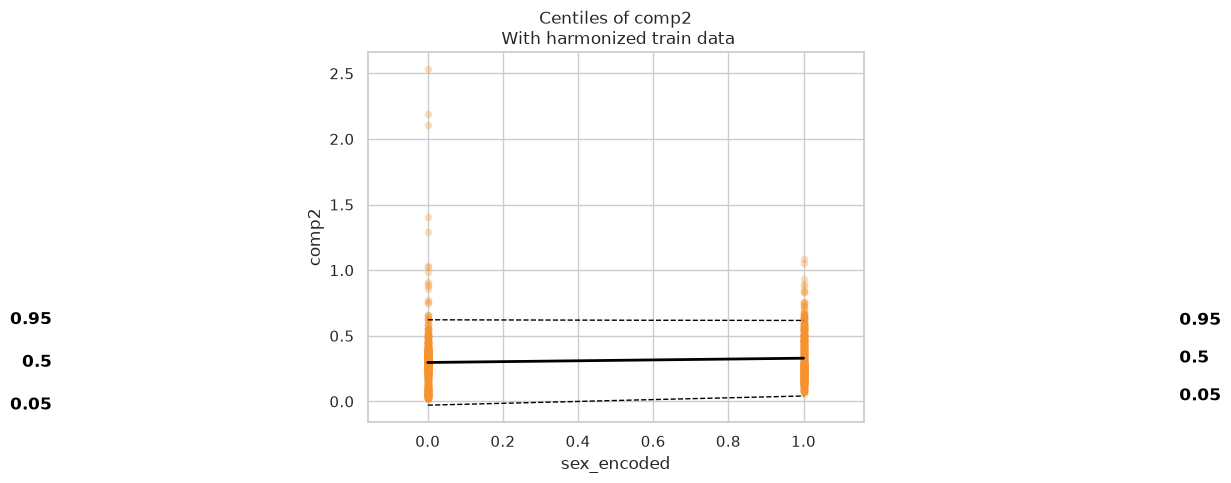

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


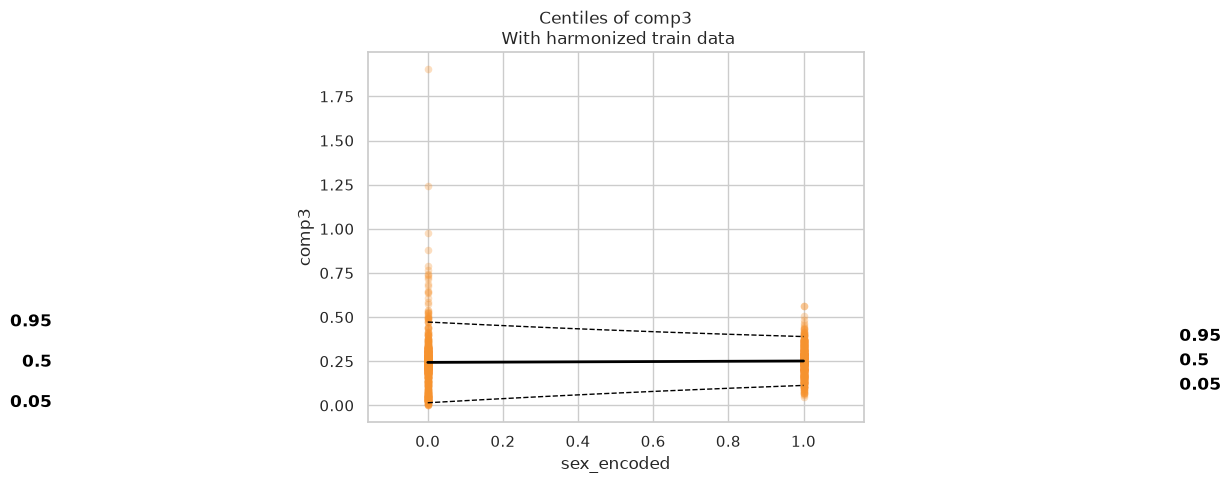

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


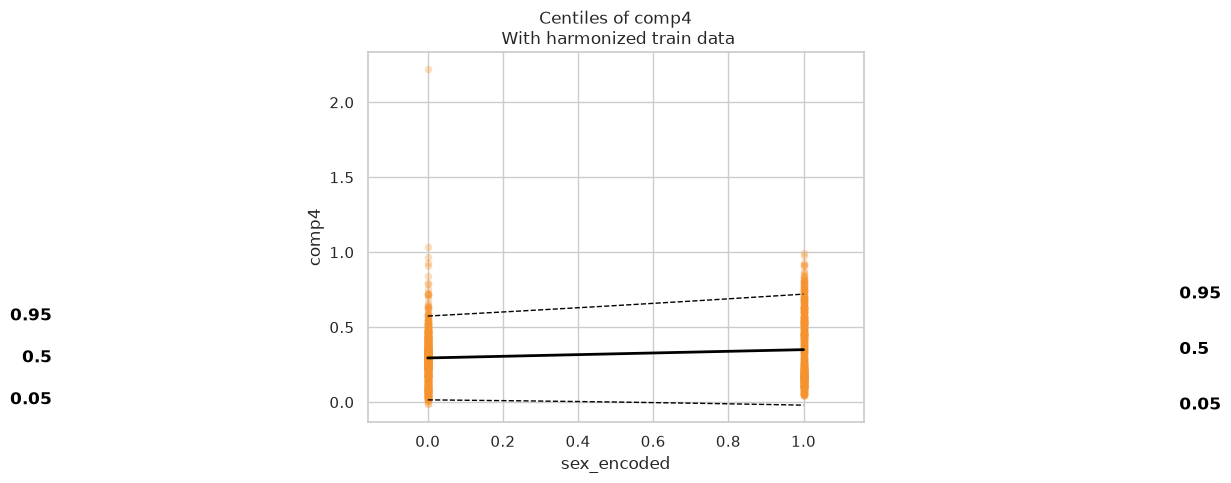

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


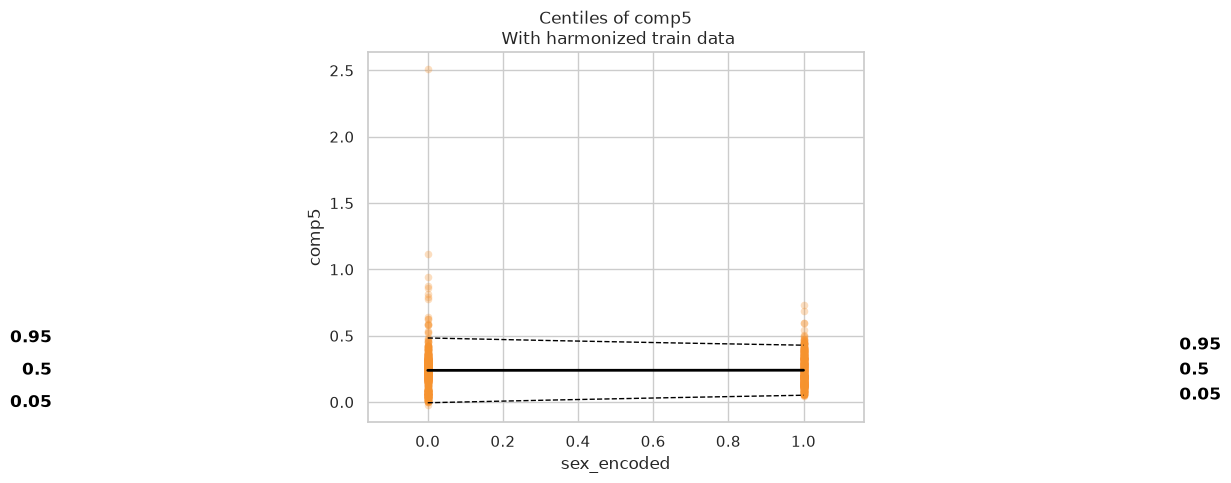

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


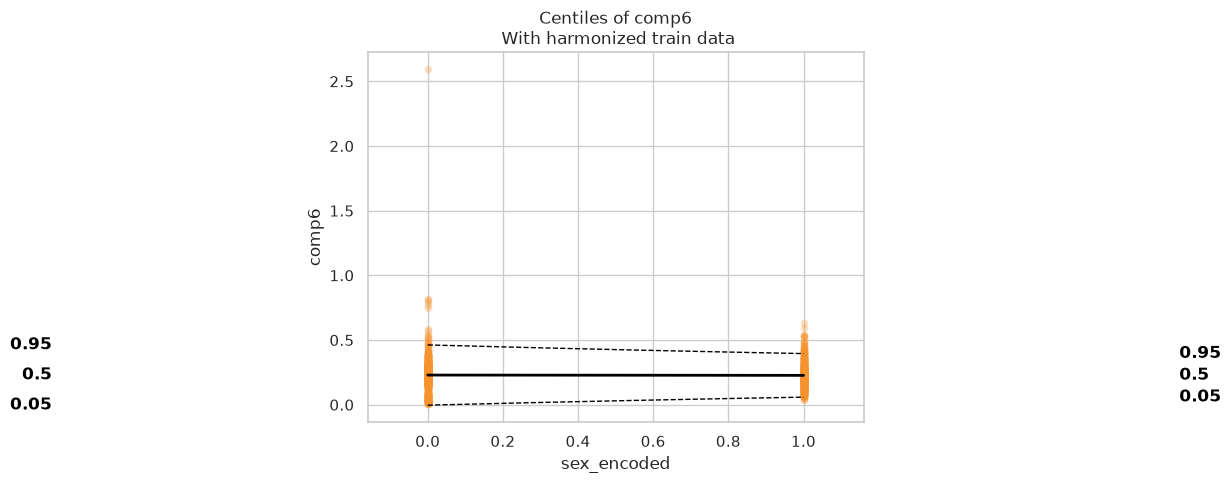

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


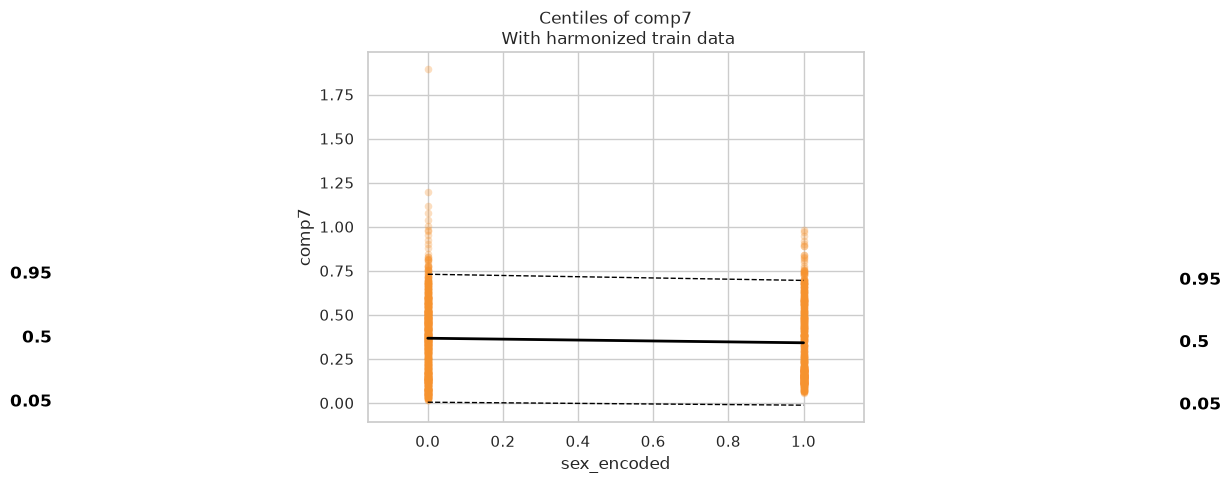

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


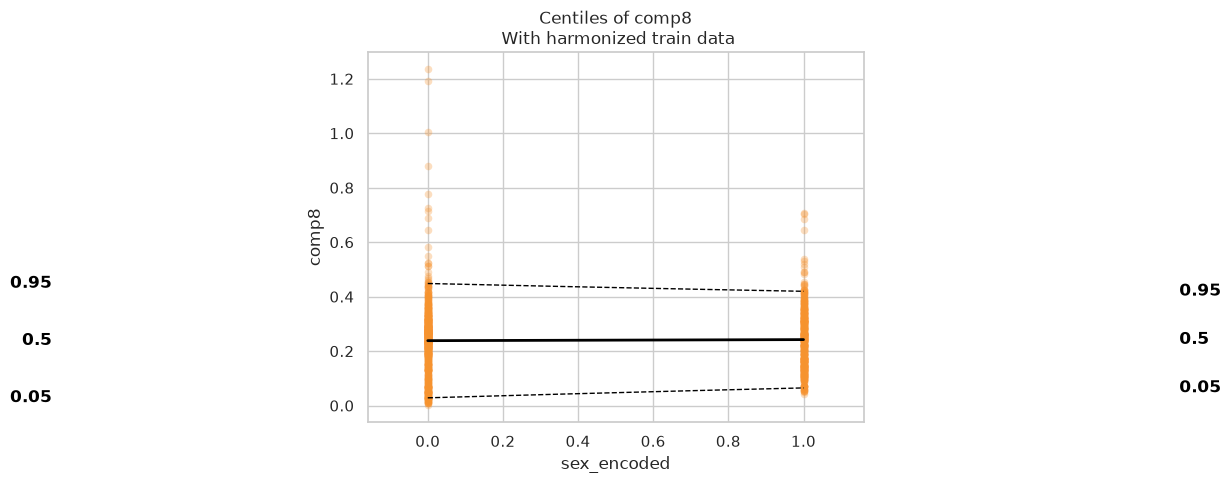

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


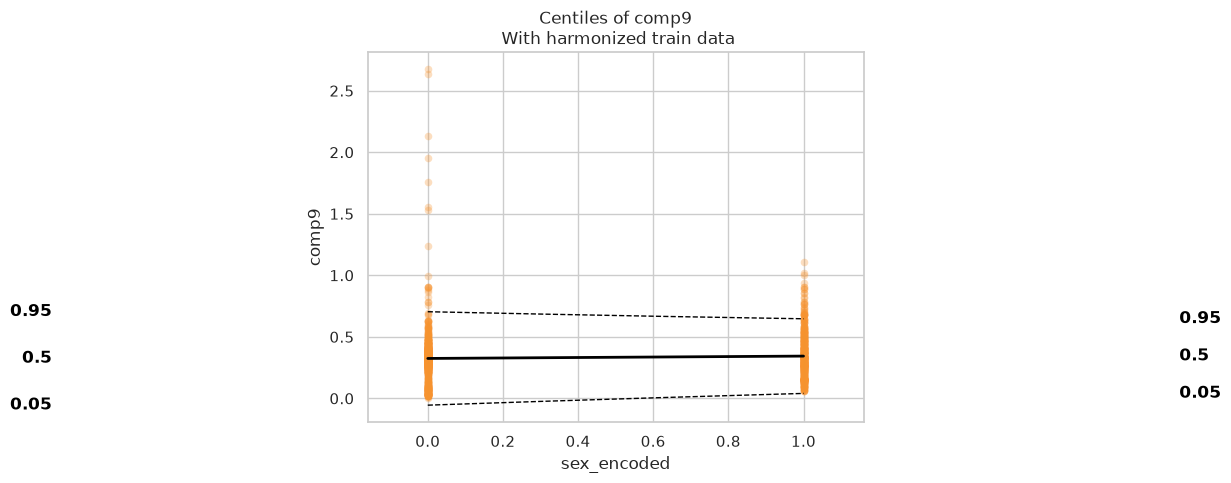

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


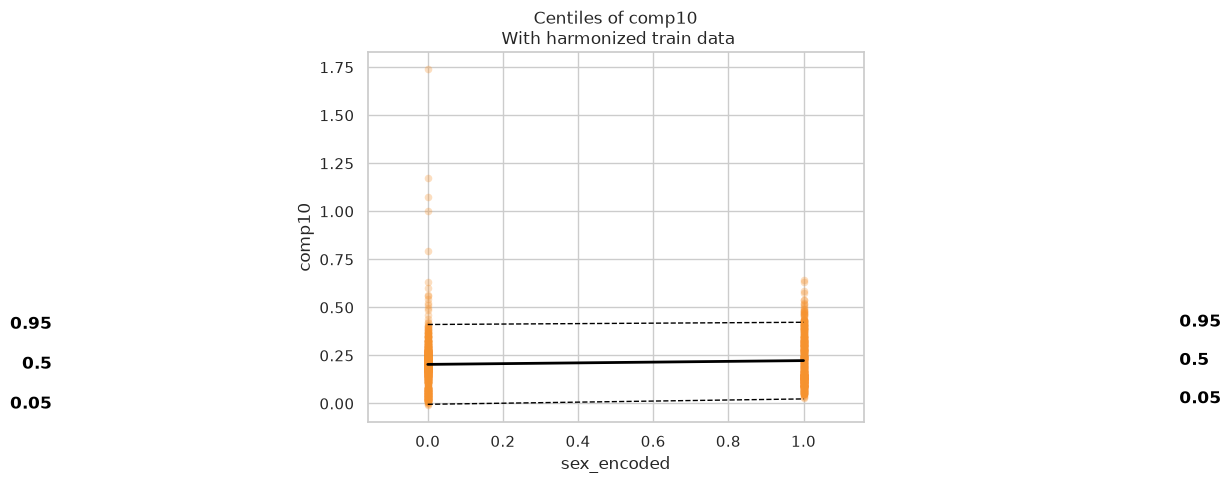

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


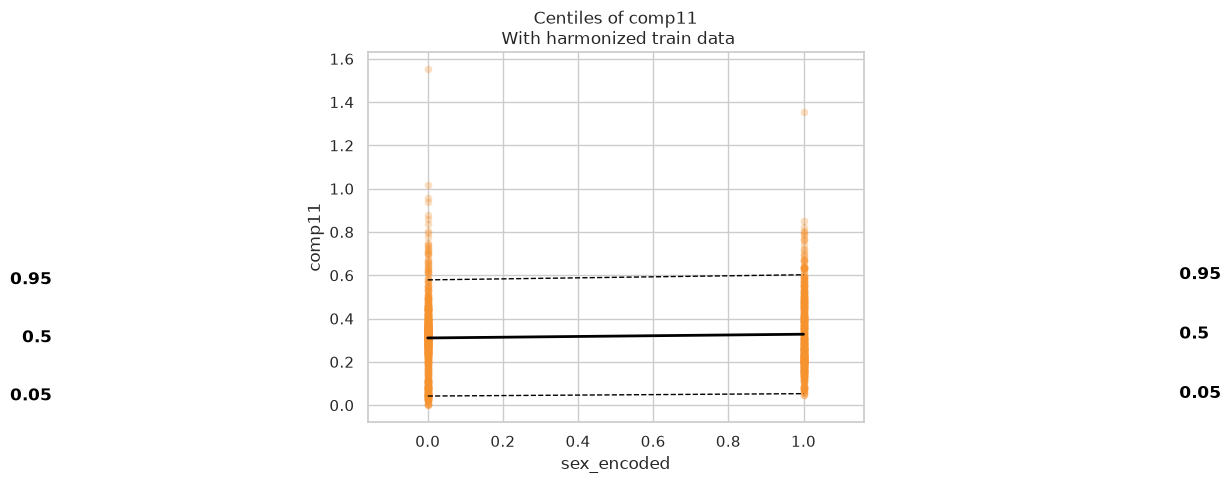

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


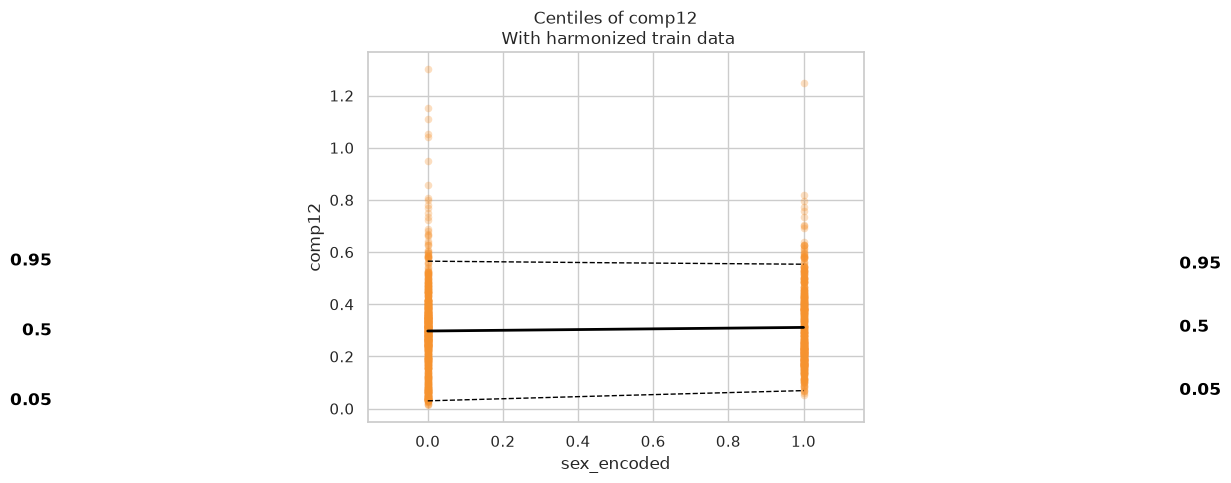

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


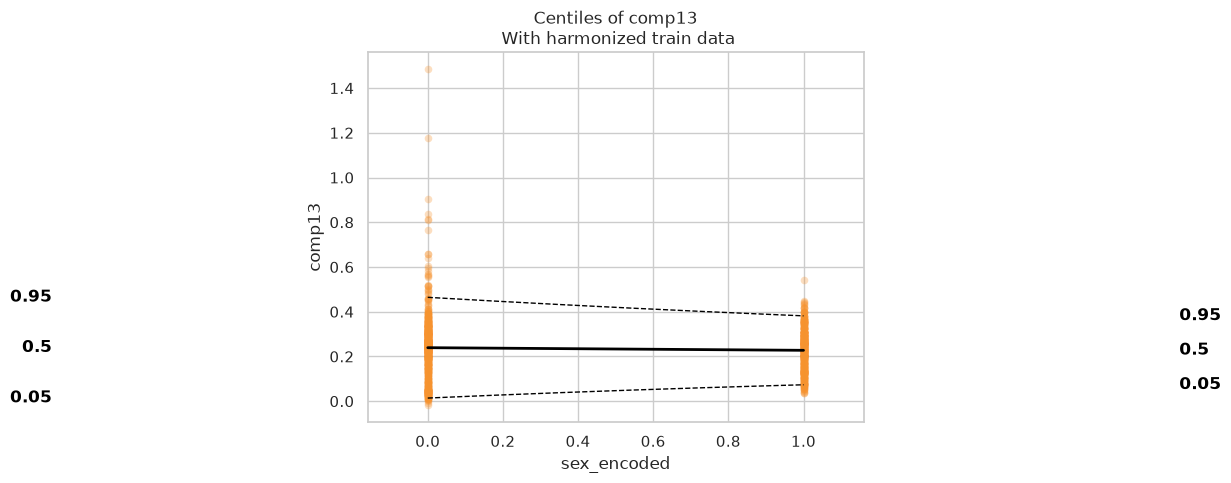

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


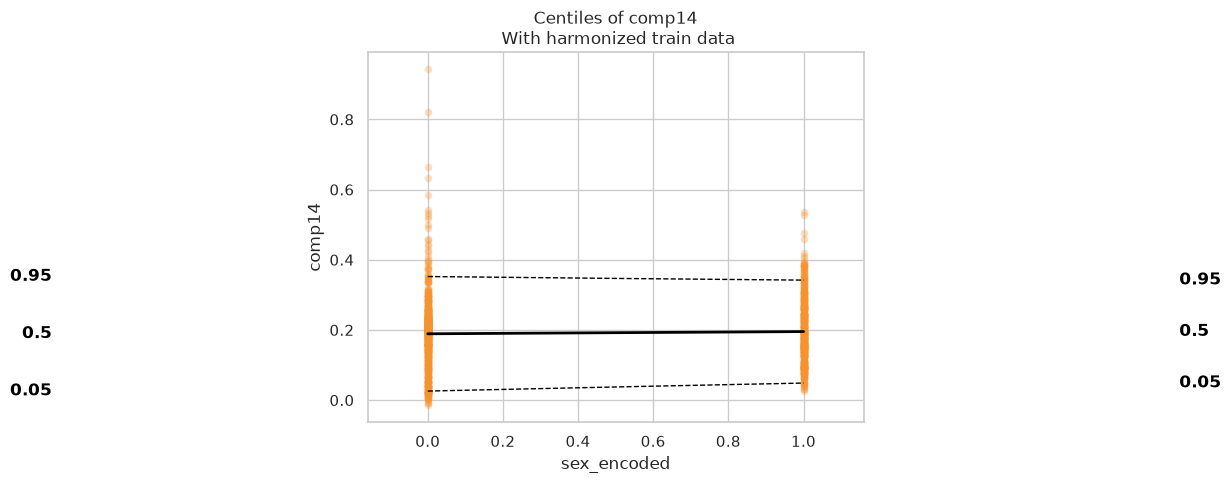

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


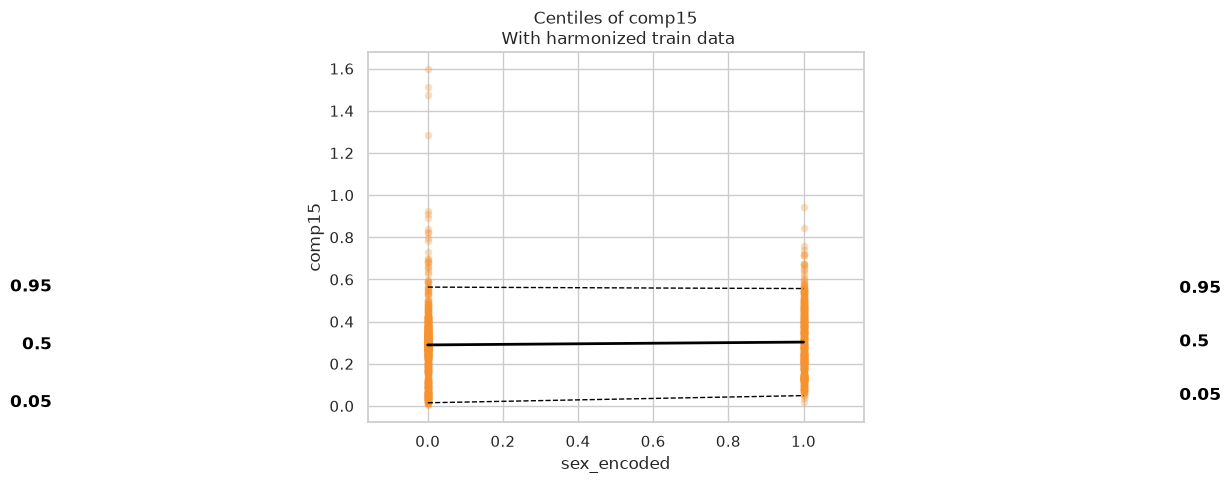

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


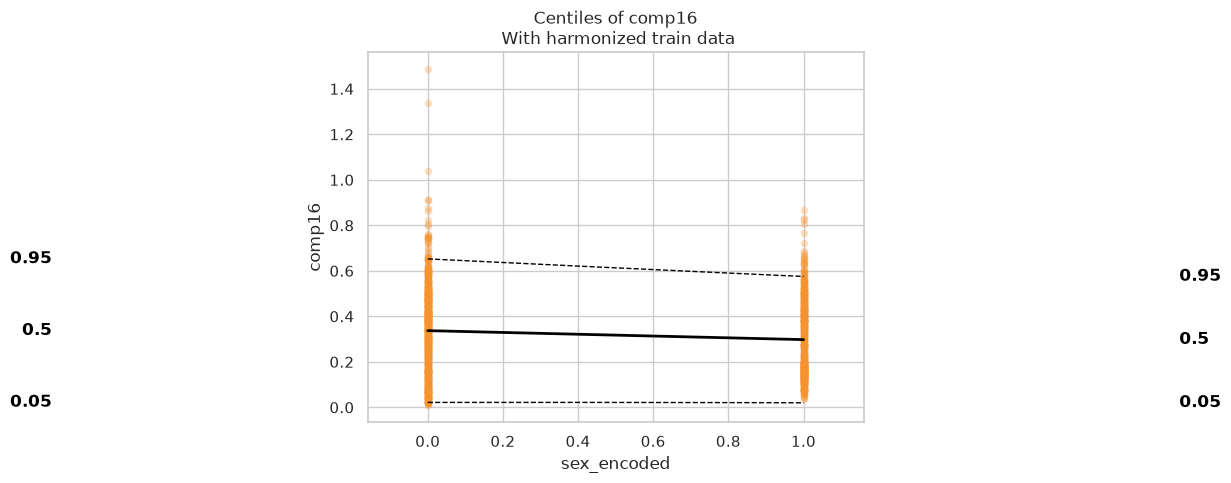

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


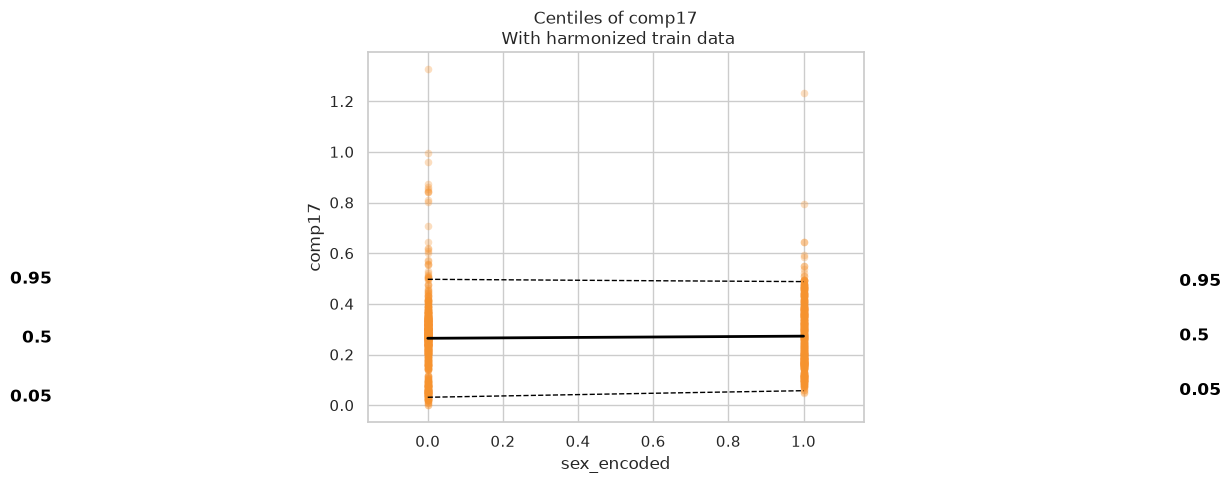

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


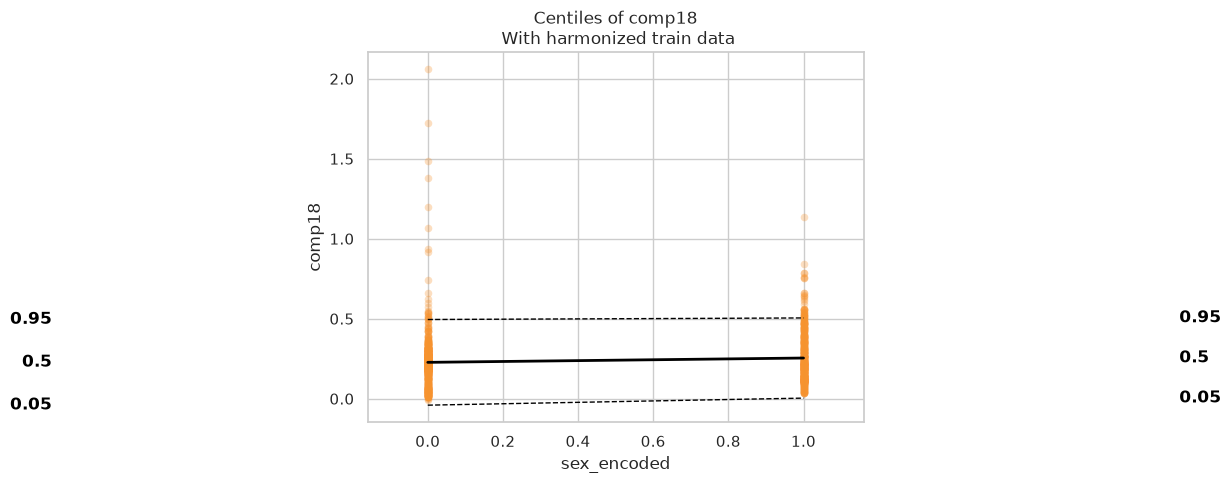

In [33]:
# Generate Evaluation Plots and Statistics
for comp in comp_cols:
    plot_centiles(
        model,
        scatter_data=train,
        response_vars=[comp],
        centiles=[0.05, 0.5, 0.95],
        covariate="sex_encoded",
        scatter_kwargs={"s": 30, "alpha": 0.3},
    )

In [29]:
# Show dataset statistics
train_stats = train.get_statistics_df().loc[comp_cols]
print("\nTrain Set Statistics:")
display(train_stats)
test_stats = test.get_statistics_df().loc[comp_cols]
print("\nTest Set Statistics:")
display(test_stats)


Train Set Statistics:


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
comp1,0.031232,2.769612,0.027874,1.143970e+00,1.385279,-0.033659,0.031232,0.286255,0.165137,3.221599e-09,0.968768,0.943106,0.943922
comp2,0.007238,26.321878,0.039843,7.591282e-01,1.410774,-0.008165,0.007238,0.188301,0.069857,1.277098e-02,0.992762,0.810125,3.242962
comp3,0.001940,19.428942,0.037323,1.123587e+00,1.354287,-0.064652,0.001918,0.119886,0.094740,7.234640e-04,0.998082,0.879222,2.183461
comp4,0.019794,13.358826,0.025669,1.021741e+00,1.390211,-0.028728,0.019794,0.193015,0.075177,7.356662e-03,0.980206,0.917103,1.737676
comp5,0.000017,47.190995,0.034488,2.206796e+00,1.398511,-0.020428,0.000017,0.134146,0.003158,9.104898e-01,0.999983,0.831027,3.680934
comp6,0.000091,66.162790,0.037953,8.482823e-01,1.387654,-0.031284,0.000091,0.125327,0.029395,2.952176e-01,0.999909,0.814841,4.355443
comp7,0.003411,1.270659,0.034331,1.068586e+00,1.417015,-0.001924,0.003411,0.218401,0.051473,6.669168e-02,0.996589,0.948441,0.736258
comp8,0.000257,7.433132,0.022835,9.327531e-01,1.409997,-0.008942,0.000257,0.119214,0.016263,5.625606e-01,0.999743,0.919861,1.346921
comp9,0.001990,24.328661,0.050394,9.754263e-01,1.402282,-0.016657,0.001990,0.211013,0.052653,6.067535e-02,0.998010,0.791208,3.265499



Test Set Statistics:


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
comp1,0.065543,1.962140,0.095177,1.126656e+00,1.260170,0.004324,-0.013425,0.248719,0.240877,0.000044,1.013425,0.920965,1.019191
comp2,-0.020578,4.679025,0.067518,7.429051e-01,1.348046,0.031077,-0.048798,0.174780,-0.072510,0.224811,1.048798,0.898698,1.550671
comp3,-0.017497,6.902836,0.060993,4.481441e-01,1.286354,0.087528,-0.037448,0.098079,-0.195767,0.000950,1.037448,0.911113,1.047736
comp4,0.015732,0.350791,0.077447,1.155603e+00,1.337778,-0.017374,-0.039152,0.186453,0.041673,0.485798,1.039152,0.937244,0.757504
comp5,-0.001104,-0.026360,0.066809,7.131967e-01,1.291257,0.064979,-0.043809,0.113037,-0.111892,0.060581,1.043809,0.960192,0.451026
comp6,0.004532,0.319951,0.080993,5.845918e-01,1.199823,0.109649,-0.074760,0.093527,0.189160,0.001416,1.074760,0.978983,0.434223
comp7,-0.004504,-0.526835,0.080993,1.280488e+00,1.352412,0.042755,-0.072586,0.203120,0.071629,0.230510,1.072586,0.925371,0.666051
comp8,-0.008290,2.695083,0.055461,6.574191e-01,1.380572,0.023170,-0.041567,0.114420,-0.210657,0.000368,1.041567,0.924439,0.938936
comp9,-0.019299,1.708309,0.071773,7.844504e-01,1.231359,0.087869,-0.076448,0.166384,-0.142288,0.016803,1.076448,0.949997,0.752600


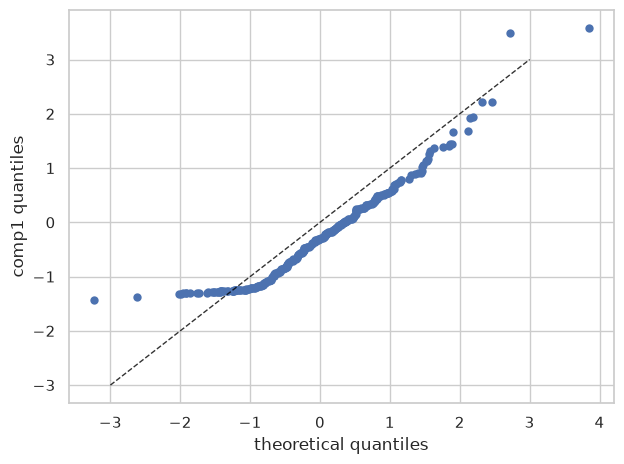

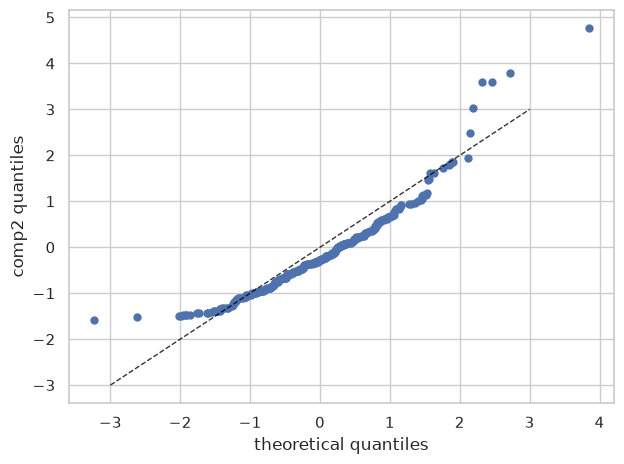

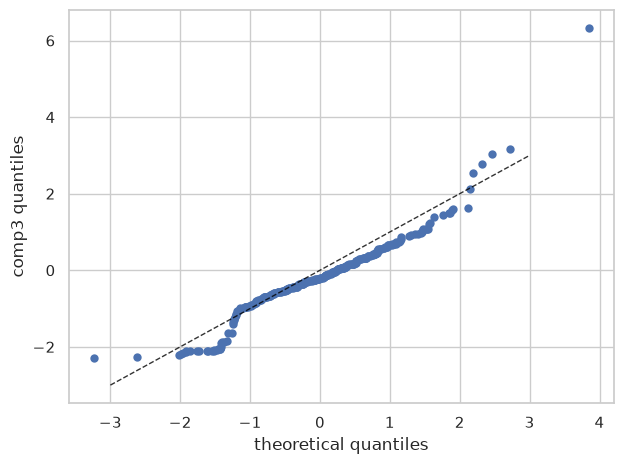

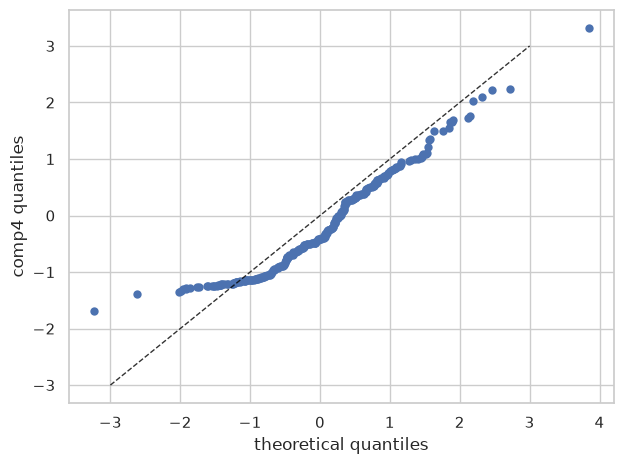

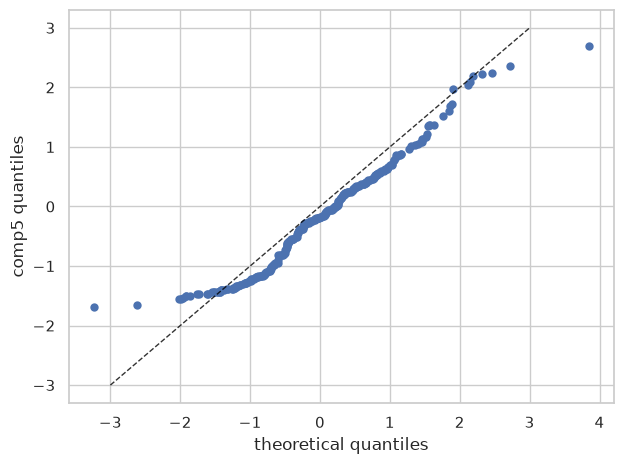

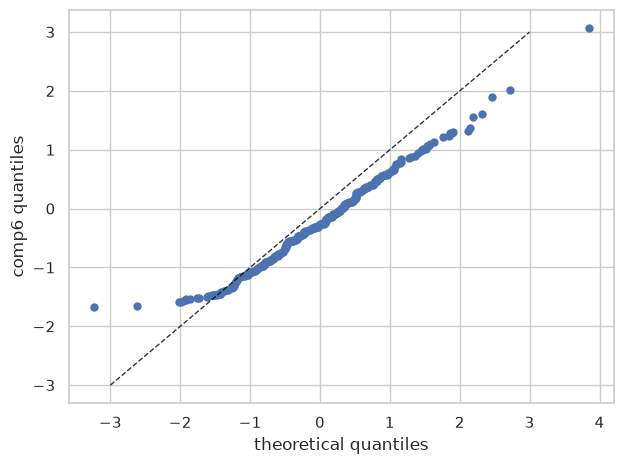

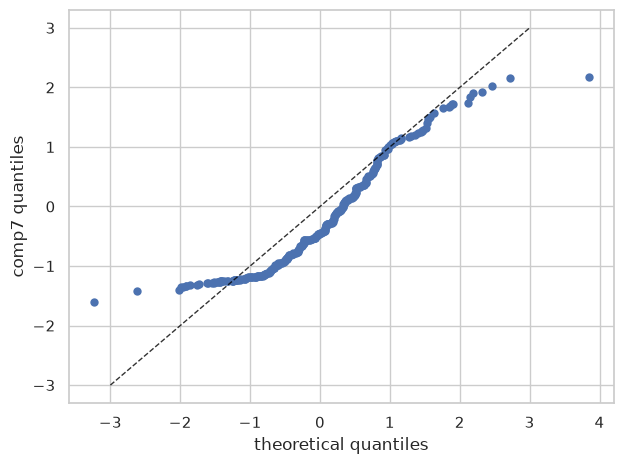

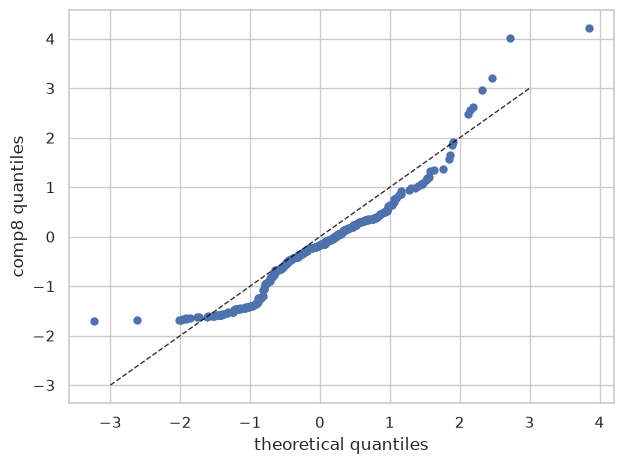

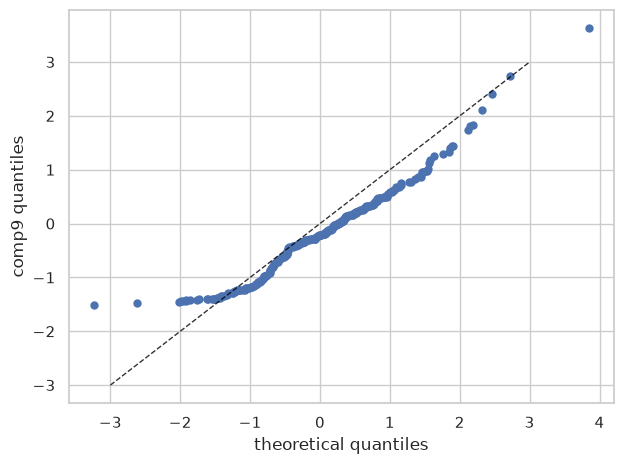

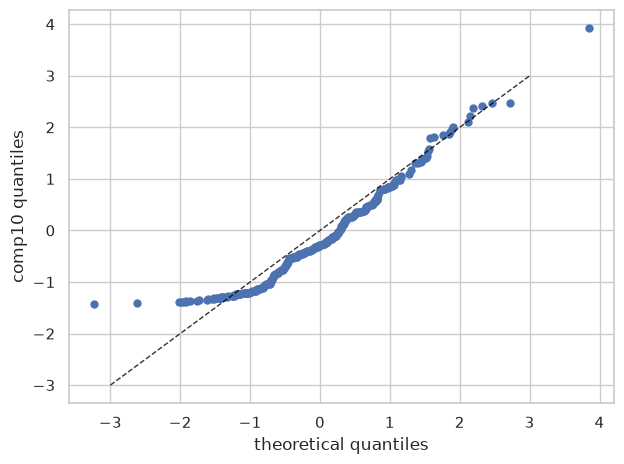

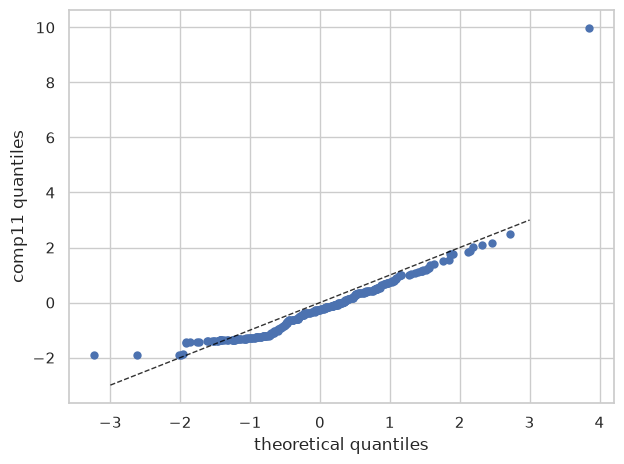

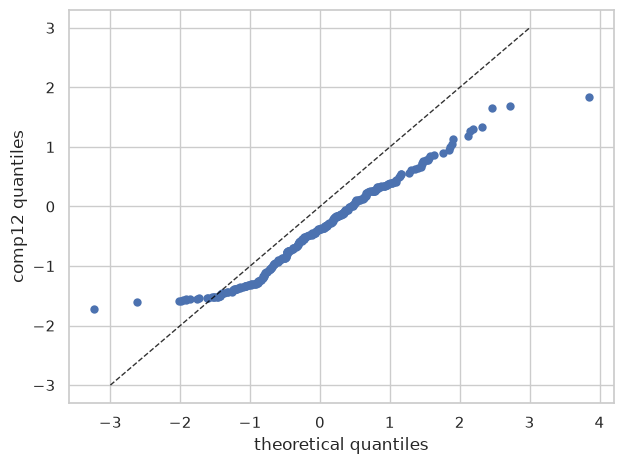

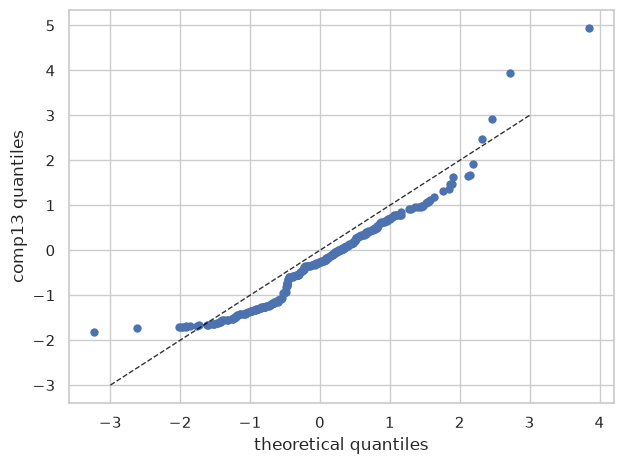

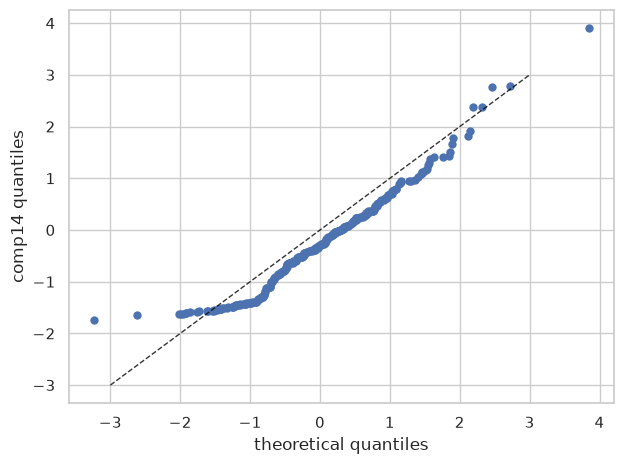

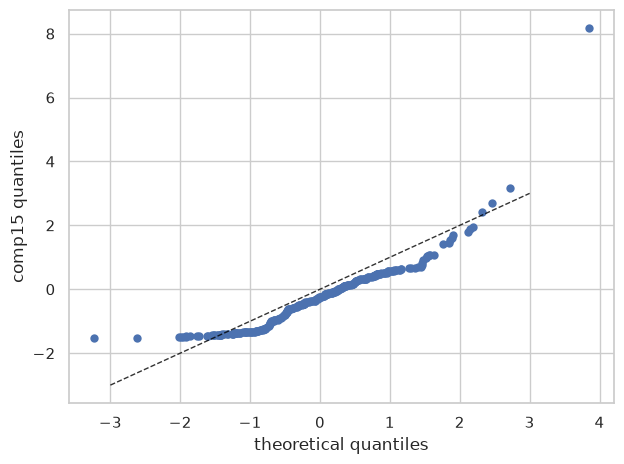

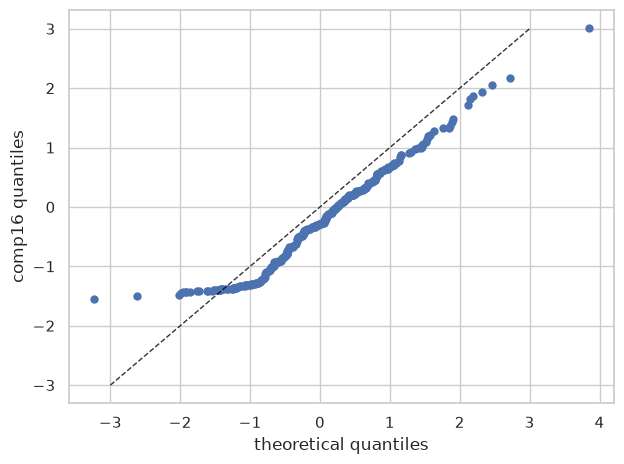

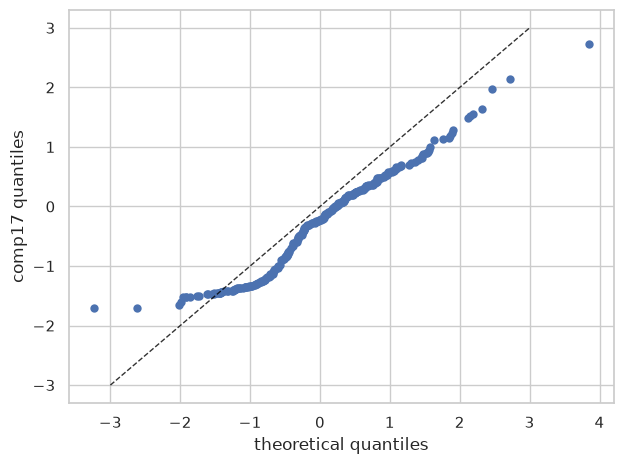

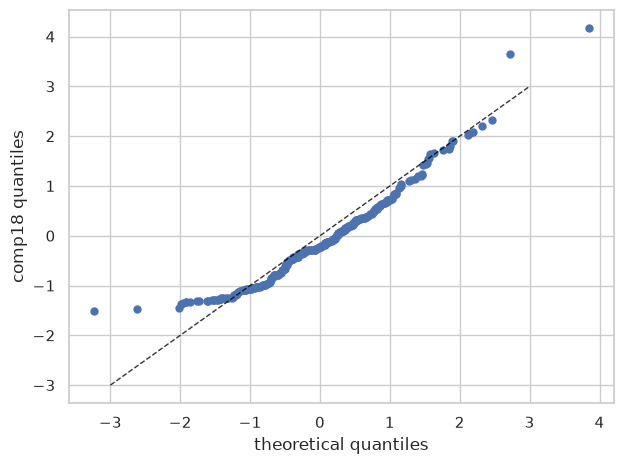

In [30]:
# QQ plot
for comp in comp_cols:
    plot_qq(test.sel({"response_vars": [comp]}), plot_id_line=True)